# Reducción de Dimensionalidad: PCA y Reconstrucción

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/11_pca_y_reconstruccion.ipynb)

## Objetivos


- Diferenciar conceptualmente entre Selección de Características (descartar variables) y Extracción de Características (comprimir variables).
- Comprender el Análisis de Componentes Principales (PCA) como un algoritmo de compresión con pérdida.
- Calcular e interpretar el **Error de Reconstrucción** al proyectar los datos de vuelta a su espacio original.
- Integrar PCA de forma segura dentro de un `Pipeline` de Scikit-Learn para evitar fugas de datos.



## Prerrequisitos


- Haber completado el repaso de PCA en el módulo de EDA: [Reducción de Dimensionalidad (PCA)](../02_eda/05_reduccion_dimensionalidad.ipynb).
- Entendimiento de la construcción de flujos de trabajo: [Pipelines y Prevención de Leakage](09_pipelines_y_prevencion_leakage.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



En el notebook [Selección de Variables y Prototipado Rápido (AutoML)](10_seleccion_variables_y_automl.ipynb), nuestra estrategia para reducir la dimensionalidad fue **Selección de Características**: evaluamos los sensores y simplemente apagamos los que menos aportaban.

Pero, ¿qué pasa si *todas* las variables aportan un poco de información útil, pero están altamente correlacionadas entre sí? Si descartamos variables, perdemos esa información. Aquí es donde entra la **Extracción de Características**.

En lugar de elegir entre la variable A o la variable B, creamos una nueva variable C que es una "mezcla" (combinación lineal) de A y B.

### PCA como un Algoritmo de Compresión


El Análisis de Componentes Principales (PCA) busca los ejes (direcciones) en el espacio de datos donde la varianza (la dispersión de la información) es máxima.

Podemos pensar en PCA como el formato MP3 para la música o el formato JPEG para las imágenes. Cuando se comprime una canción a MP3, el algoritmo elimina las frecuencias que el oído humano apenas percibe. El archivo pesa un 10% del original, pero suena casi idéntico.

PCA hace lo mismo con los datos tabulares:
1. **Comprime:** Proyecta un dataset de 100 columnas a, digamos, 15 Componentes Principales.
2. **Descomprime (Reconstruye):** A partir de esas 15 componentes, intenta reconstruir las 100 columnas originales.
3. **Pérdida (Error de Reconstrucción):** Como eliminamos las componentes menos importantes (el "ruido"), la reconstrucción no será bit a bit idéntica al original. Esa diferencia matemática es el error de reconstrucción.

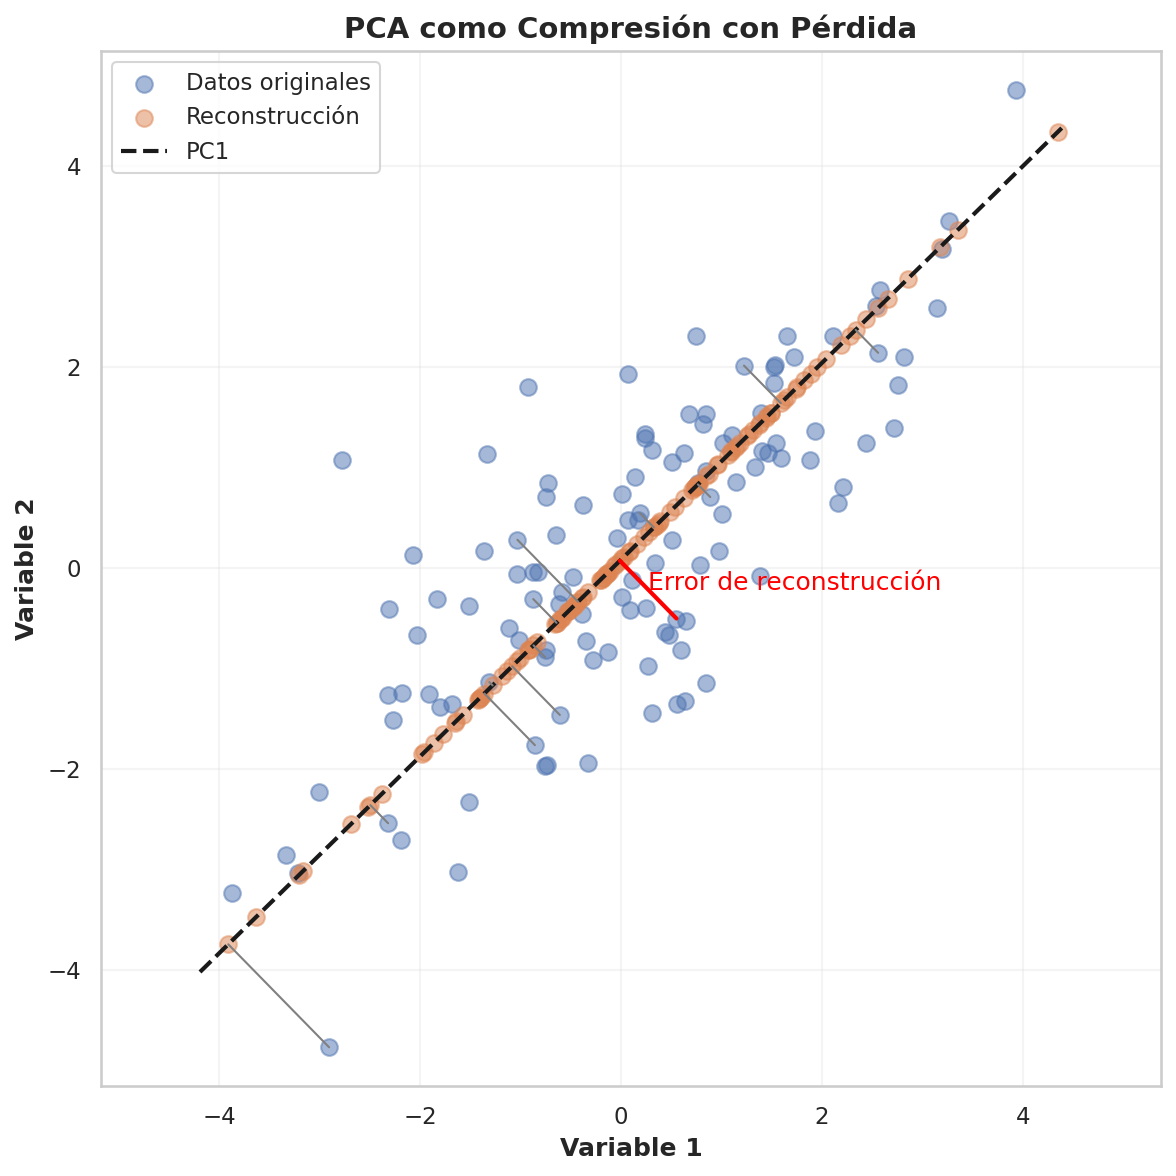

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Seed para reproducibilidad
np.random.seed(42)

# Generar datos 2D correlacionados (óvalo inclinado)
mean = [0, 0]
cov = [[3, 2.5],
       [2.5, 3]]
X = np.random.multivariate_normal(mean, cov, 120)

# PCA "manual"
# Centrar datos
X_mean = X.mean(axis=0)
X_centered = X - X_mean

# SVD para obtener PC1
U, S, Vt = np.linalg.svd(X_centered)
pc1 = Vt[0]  # primer componente principal (vector unitario)

# Proyección (compresión a 1D)
X_proj_1d = X_centered @ pc1

# Reconstrucción (volver a 2D)
X_recon = np.outer(X_proj_1d, pc1) + X_mean


plt.figure(figsize=(8, 8))
# Puntos originales
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label="Datos originales")
# Puntos reconstruidos
plt.scatter(X_recon[:, 0], X_recon[:, 1], alpha=0.5, label="Reconstrucción")

# Línea PC1
line = np.linspace(-6, 6, 100)
pc1_line = np.outer(line, pc1) + X_mean
plt.plot(pc1_line[:, 0], pc1_line[:, 1], 'k--', linewidth=2, label="PC1")

# Proyecciones (líneas perpendiculares)
for i in range(0, len(X), 10):  # no saturar visualmente
    plt.plot([X[i, 0], X_recon[i, 0]],
             [X[i, 1], X_recon[i, 1]],
             'gray', linewidth=1)

# Ejemplo de error destacado
i = 16
plt.plot([X[i, 0], X_recon[i, 0]],
         [X[i, 1], X_recon[i, 1]],
         'red', linewidth=2)

plt.text((X[i, 0] + X_recon[i, 0]) / 2,
         (X[i, 1] + X_recon[i, 1]) / 2,
         "Error de reconstrucción",
         color='red')

plt.title("PCA como Compresión con Pérdida", fontsize=14)
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Desarrollo e Implementación


Vamos a trabajar con el **Wine Clustering Dataset**, que contiene 13 características químicas de diferentes vinos. Nuestro objetivo es comprimir esta información.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine

# Carga de datos desde datasets de scikit-learn
df = load_wine(as_frame=True)

# Dimensiones originales
print(f"Dimensiones originales: {df.data.shape}")

# Convertir a dataframe
df = df.frame
df

Dimensiones originales: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


### El Peligro de las Escalas (Por qué `StandardScaler` no es opcional)



PCA busca las direcciones de **máxima varianza**. La varianza se mide en las unidades originales al cuadrado. Veamos qué pasa si calculamos la varianza de nuestros datos crudos.



/tmp/ipykernel_6951/1057225985.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=varianzas.values, y=varianzas.index, palette='Reds_r')


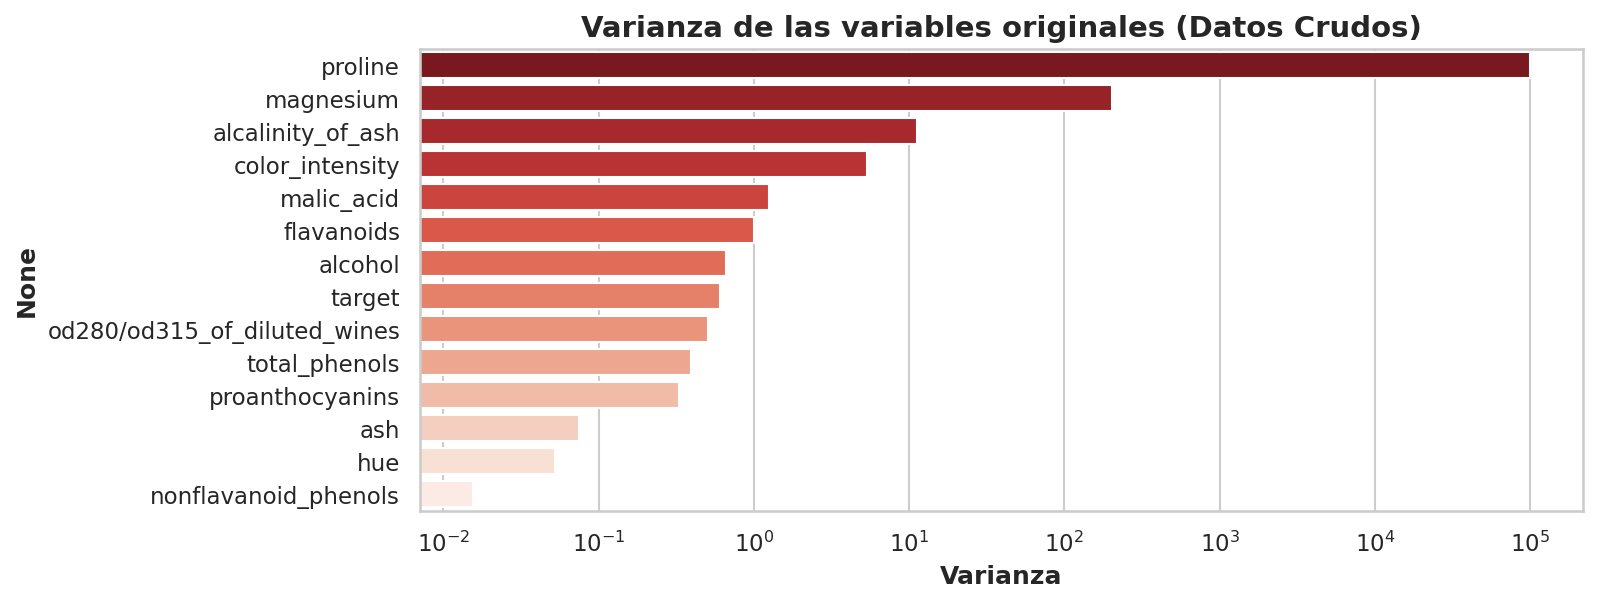

In [23]:
# Calculamos la varianza de cada columna
varianzas = df.var().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=varianzas.values, y=varianzas.index, palette='Reds_r')
plt.title("Varianza de las variables originales (Datos Crudos)")
plt.xlabel("Varianza")
plt.xscale('log') # Usamos escala logarítmica para poder ver las variables pequeñas
plt.show()

Observar el gráfico. La variable `Proline` tiene una varianza en el orden de los millones, mientras que `Nonflavanoid_Phenols` tiene una varianza de fracciones decimales.

Si aplicamos PCA ahora mismo, el algoritmo dirá (*suponiendo que pueda hablar, y encima hable así*): *"¡Eureka! El 99.9% de la información de este dataset está en la columna Proline"*. Ignorará por completo la química sutil del vino simplemente porque el Proline se midió en unidades más grandes.

**Regla de Ingeniería:** Jamás aplicar PCA sin estandarizar los datos previamente para que todas las variables tengan varianza = 1.

In [24]:
# División Train/Test (Siempre antes de escalar)
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Entrenando PCA y el Gráfico de Varianza Explicada



Ahora sí, aplicamos PCA y utilizamos el *Scree Plot* (Gráfico de Codo) para decidir cuántas componentes retener.



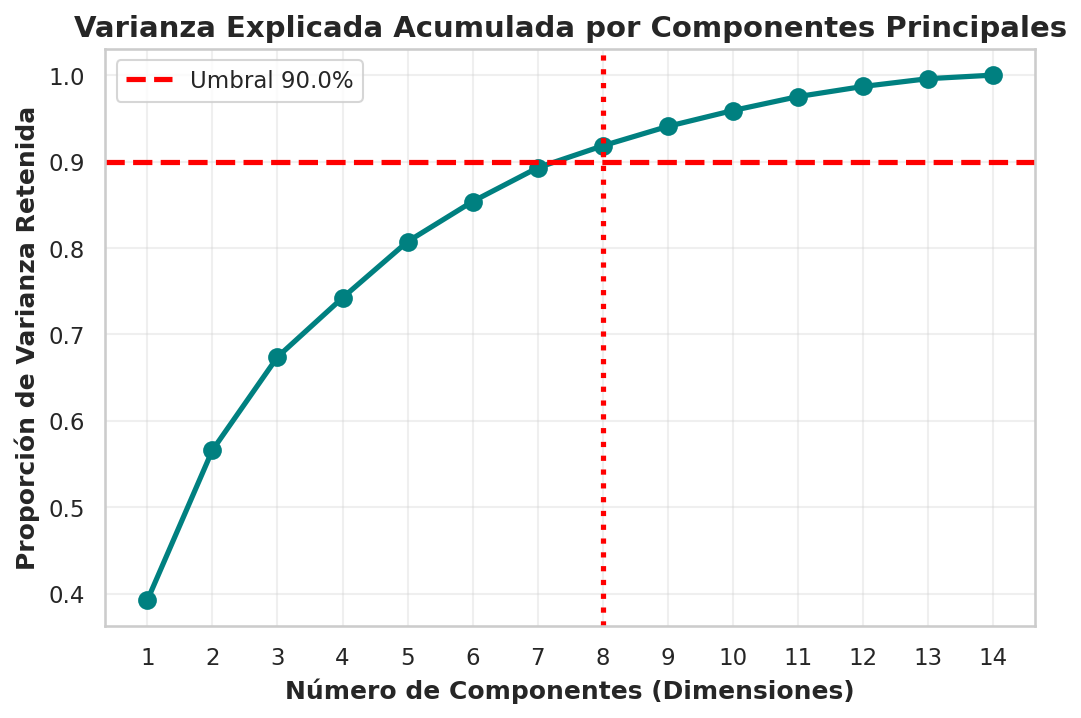

Para retener el 90.0% de la información, necesitamos 8 componentes.


In [25]:
# Instanciamos PCA sin limitar componentes para analizar el espectro completo
pca = PCA(n_components=None, random_state=42)
pca.fit(X_train_scaled)

# Calculamos la varianza explicada acumulada
varianza_acumulada = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='-', color='teal')

# Dibujamos un umbral de decisión típico en ingeniería (90% de la información)
# la elección siempre depende del contexto y problema a tratar (por las dudas)
umbral = 0.90
plt.axhline(y=umbral, color='red', linestyle='--', label=f'Umbral {umbral*100}%')

# Encontramos cuántas componentes cruzan el umbral
num_componentes_90 = np.argmax(varianza_acumulada >= umbral) + 1
plt.axvline(x=num_componentes_90, color='red', linestyle=':')

plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes (Dimensiones)')
plt.ylabel('Proporción de Varianza Retenida')
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Para retener el {umbral*100}% de la información, necesitamos {num_componentes_90} componentes.")


Hemos logrado reducir el problema de 13 dimensiones a solo 8, reteniendo el 90% de la varianza original.



### La Magia de la Reconstrucción


Vamos a comprimir un vino del *Test Set* a 8 dimensiones, y luego intentamos reconstruir sus 13 características químicas originales a partir de esa versión comprimida.

In [26]:
# 1. Re-entrenamos PCA solo con las 8 componentes óptimas
pca_optimo = PCA(n_components=num_componentes_90, random_state=42)
pca_optimo.fit(X_train_scaled)

# 2. COMPRESIÓN: Transformamos el Test Set (De 13D a 8D)
X_test_comprimido = pca_optimo.transform(X_test_scaled)

# 3. DESCOMPRESIÓN: Reconstruimos el Test Set (De 8D a 13D)
X_test_reconstruido = pca_optimo.inverse_transform(X_test_comprimido)

# Comparamos el primer vino del Test Set
vino_original = X_test_scaled[0]
vino_reconstruido = X_test_reconstruido[0]

# Calculamos el Error de Reconstrucción (MSE) para este vino
error_mse = np.mean((vino_original - vino_reconstruido)**2)

print("--- Comparación de Características (Estandarizadas) ---")
df_comparacion = pd.DataFrame({
    'Original (13D)': vino_original,
    'Reconstruido desde 8D': vino_reconstruido,
    'Diferencia Absoluta': np.abs(vino_original - vino_reconstruido)
}, index=df.columns)

display(df_comparacion.head(5))
print(f"\nError Cuadrático Medio (MSE) de Reconstrucción: {error_mse:.4f}")

--- Comparación de Características (Estandarizadas) ---


,Original (13D),Reconstruido desde 8D,Diferencia Absoluta
alcohol,0.808733,0.716000,0.092733
malic_acid,0.637319,0.662100,0.024781
ash,0.715786,0.378229,0.337557
alcalinity_of_ash,-1.241280,-0.800982,0.440299
magnesium,1.065567,1.002326,0.063241



Error Cuadrático Medio (MSE) de Reconstrucción: 0.0661


## Resultados y Discusión


Observar la tabla superior. Los valores reconstruidos no son exactamente iguales a los originales, pero son **extremadamente cercanos**. Hemos recuperado la "receta química" del vino utilizando solo el 60% del espacio de almacenamiento original.

**¿Para qué sirve el Error de Reconstrucción en la vida real?**  
Guardar este concepto para más adelante, porque será la base para la **Detección de Anomalías**.    
Si entrenamos un PCA *solo* con transacciones bancarias normales (o una muy baja tasa de anormales/posible fraude), el algoritmo aprenderá a comprimir y descomprimir transacciones normales con un error muy bajo. Pero si de repente intentamos comprimir y descomprimir una transacción **fraudulenta** (que tiene patrones extraños que el PCA nunca vio), el algoritmo fallará miserablemente y el Error de Reconstrucción se disparará. ¡Esa es nuestra alarma de fraude!

### Integración Profesional: PCA en Pipelines



Como vimos en el notebook [Pipelines y Prevención de Data Leakage](09_pipelines_y_prevencion_leakage.ipynb), hacer `fit_transform` suelto por el código es peligroso. Si se va a usar PCA como paso previo a un modelo predictivo (ej. Regresión Logística), debes embutirlo en un Pipeline.

Scikit-Learn nos permite pasar un número flotante (ej. `0.90`) al parámetro `n_components`. El algoritmo calculará automáticamente cuántas componentes necesita para retener ese porcentaje de varianza.

In [27]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

# Construcción de un flujo de trabajo robusto y sin Leakage
pipeline_produccion = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.90, random_state=42), # Retener 90% de varianza dinámicamente
    LogisticRegression()
)

# Este pipeline está listo para ser entrenado con (X_train, y_train)
# pipeline_produccion.fit(X_train, y_train)

In [28]:
pipeline_produccion

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=0.9, random_state=42)),
                ('logisticregression', LogisticRegression())])

## Conexiones y Próximos Pasos



PCA es rápido, elegante y matemáticamente perfecto... siempre y cuando las relaciones entre las variables sean **lineales**.

Pero, ¿qué pasa si los datos tienen una topología compleja, como un papel arrugado o un espiral en 3D? PCA intentará aplastarlos con una línea recta y destruirá la estructura de los grupos.

- ➡️ **Siguiente:** En el [Manifold Learning y t-SNE](12_manifold_learning_tsne.ipynb), abandonamos las proyecciones lineales. Aprendemos cómo algoritmos avanzados logran "desenrollar" datos complejos para visualizarlos en 2D, y por qué **jamás** se debe usar t-SNE en un Pipeline de producción.
- 🔄 **Relacionado:** ...

## Referencias


1. Shlens, J. (2014). *A tutorial on principal component analysis*. arXiv preprint arXiv:1404.1100.
2. [Scikit-Learn: PCA Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

---

## Entorno de Ejecución


In [29]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
